# 📊 Funda Data - Exploratory Data Analysis

This notebook explores the scraped Funda.nl housing data and provides insights.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Pandas display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Load Data

In [3]:
# Load the scraped data
# Replace with your actual filename
df = pd.read_csv('../data/raw/funda_cleaned.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1014, 9)


,url,scraped_at,price,living_area_m2,rooms,bedrooms,address,build_year,energy_label
0,https://www.funda.nl/detail/koop/amsterdam/app...,2026-03-20T02:01:53.380615,425000,51,3,1.0,Fagelstraat 62-21052 GE AmsterdamFrederik Hend...,NaN,NaN
1,https://www.funda.nl/detail/koop/amsterdam/app...,2026-03-20T02:01:59.385680,980000,129,3,2.0,Radarweg 4481043 NV AmsterdamSloterdijk Statio...,2023.0,A++
2,https://www.funda.nl/detail/koop/amsterdam/app...,2026-03-20T02:02:05.899752,495000,56,2,1.0,Kromme Leimuidenstraat 5-11059 EL AmsterdamAal...,2015.0,C
3,https://www.funda.nl/detail/koop/amsterdam/app...,2026-03-20T02:02:11.800700,425000,44,2,1.0,Ten Katestraat 47-11053 BX AmsterdamBellamybuu...,1894.0,NaN
4,https://www.funda.nl/detail/koop/amsterdam/app...,2026-03-20T02:02:17.285746,595000,120,4,3.0,Humberto Delgadoplein 341102 JM AmsterdamF-buurt,2003.0,A


## 2. Data Overview

In [4]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             1014 non-null   object 
 1   scraped_at      1014 non-null   object 
 2   price           1014 non-null   int64  
 3   living_area_m2  1014 non-null   int64  
 4   rooms           1014 non-null   int64  
 5   bedrooms        1011 non-null   float64
 6   address         1014 non-null   object 
 7   build_year      429 non-null    float64
 8   energy_label    745 non-null    object 
dtypes: float64(2), int64(3), object(4)
memory usage: 71.4+ KB


In [5]:
# Statistical summary
df.describe()

,price,living_area_m2,rooms,bedrooms,build_year
count,1.014000e+03,1014.000000,1014.000000,1011.000000,429.000000
mean,5.754534e+05,104.235700,4.003945,2.784372,1969.193473
std,3.033999e+05,48.669977,1.526981,1.274655,55.987043
min,1.750000e+05,25.000000,1.000000,1.000000,1450.000000
25%,3.900000e+05,72.000000,3.000000,2.000000,1936.000000
50%,4.990000e+05,96.500000,4.000000,3.000000,1982.000000
75%,6.500000e+05,125.750000,5.000000,4.000000,2006.000000
max,2.495000e+06,447.000000,13.000000,8.000000,2026.000000


In [6]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Missing values:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")

Missing values:
build_year      585
energy_label    269
bedrooms          3
dtype: int64

Total missing: 857


## 3. Price Analysis

In [7]:
# Price statistics
print(f"Average price: €{df['price'].mean():,.0f}")
print(f"Median price:  €{df['price'].median():,.0f}")
print(f"Min price:     €{df['price'].min():,.0f}")
print(f"Max price:     €{df['price'].max():,.0f}")

Average price: €575,453
Median price:  €499,000
Min price:     €175,000
Max price:     €2,495,000


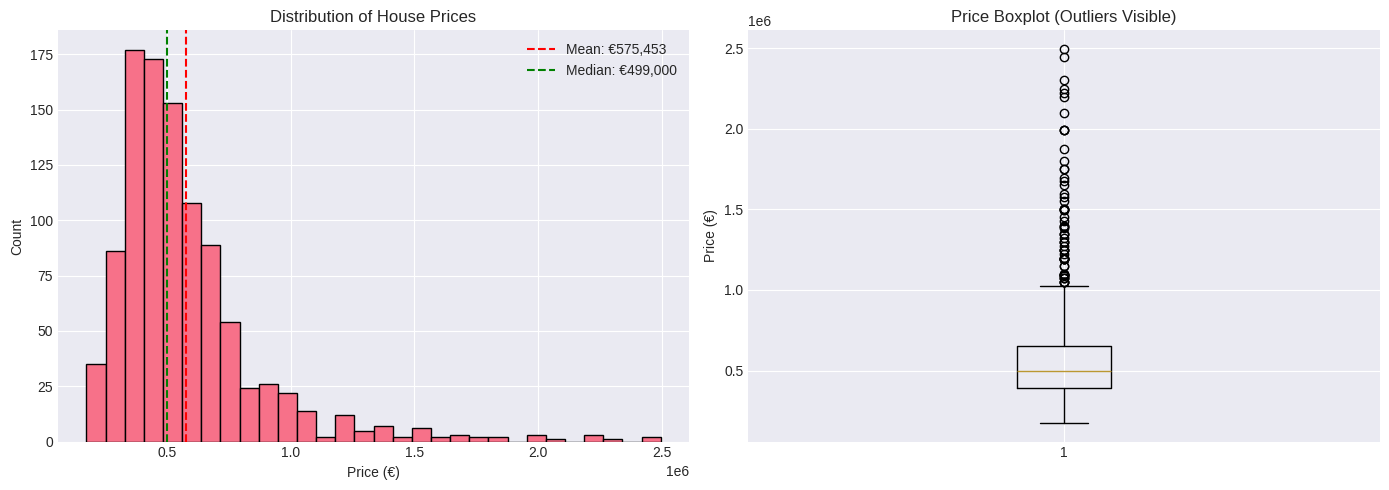

In [8]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price'].dropna(), bins=30, edgecolor='black')
axes[0].set_xlabel('Price (€)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of House Prices')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f'Mean: €{df["price"].mean():,.0f}')
axes[0].axvline(df['price'].median(), color='green', linestyle='--', label=f'Median: €{df["price"].median():,.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['price'].dropna())
axes[1].set_ylabel('Price (€)')
axes[1].set_title('Price Boxplot (Outliers Visible)')

plt.tight_layout()
plt.show()

## 4. Living Area Analysis

In [9]:
# Living area statistics
print(f"Average living area: {df['living_area_m2'].mean():.0f} m²")
print(f"Median living area:  {df['living_area_m2'].median():.0f} m²")

Average living area: 104 m²
Median living area:  96 m²


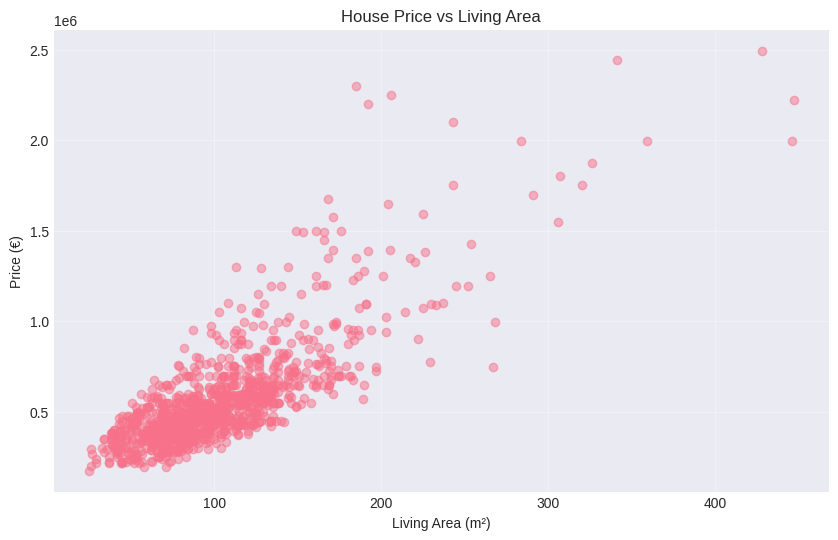

In [10]:
# Price vs Living Area
plt.figure(figsize=(10, 6))
plt.scatter(df['living_area_m2'], df['price'], alpha=0.5)
plt.xlabel('Living Area (m²)')
plt.ylabel('Price (€)')
plt.title('House Price vs Living Area')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Price per m² Analysis

In [11]:
# Calculate price per m²
df['price_per_m2'] = df['price'] / df['living_area_m2']

print(f"Average price per m²: €{df['price_per_m2'].mean():,.0f}")
print(f"Median price per m²:  €{df['price_per_m2'].median():,.0f}")

Average price per m²: €5,716
Median price per m²:  €5,295


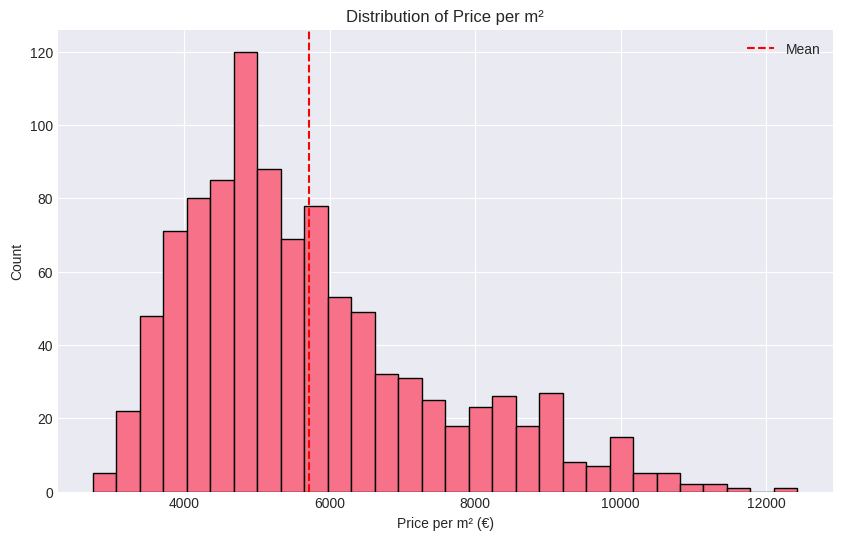

In [12]:
# Price per m² distribution
plt.figure(figsize=(10, 6))
plt.hist(df['price_per_m2'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Price per m² (€)')
plt.ylabel('Count')
plt.title('Distribution of Price per m²')
plt.axvline(df['price_per_m2'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

## 6. House Type Analysis

In [13]:
# House type distribution
house_type_counts = df['house_type'].value_counts()
print("House type distribution:")
print(house_type_counts)

KeyError: 'house_type'

In [ ]:
# Average price by house type
avg_price_by_type = df.groupby('house_type')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_price_by_type.plot(kind='bar')
plt.xlabel('House Type')
plt.ylabel('Average Price (€)')
plt.title('Average Price by House Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Build Year Analysis

In [ ]:
# Build year distribution
plt.figure(figsize=(12, 6))
plt.hist(df['build_year'].dropna(), bins=50, edgecolor='black')
plt.xlabel('Build Year')
plt.ylabel('Count')
plt.title('Distribution of Build Years')
plt.show()

In [ ]:
# Price vs Build Year
plt.figure(figsize=(12, 6))
plt.scatter(df['build_year'], df['price'], alpha=0.5)
plt.xlabel('Build Year')
plt.ylabel('Price (€)')
plt.title('Price vs Build Year')
plt.grid(True, alpha=0.3)
plt.show()

## 8. Energy Label Analysis

In [ ]:
# Energy label distribution
energy_counts = df['energy_label'].value_counts()
print("Energy label distribution:")
print(energy_counts)

In [ ]:
# Average price by energy label
avg_price_by_energy = df.groupby('energy_label')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_price_by_energy.plot(kind='bar')
plt.xlabel('Energy Label')
plt.ylabel('Average Price (€)')
plt.title('Average Price by Energy Label')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Correlation Analysis

In [ ]:
# Select numeric columns
numeric_cols = ['price', 'living_area_m2', 'plot_area_m2', 'rooms', 'bedrooms', 'build_year']
numeric_cols = [col for col in numeric_cols if col in df.columns]

# Correlation matrix
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 10. Key Insights

**Summary of findings:**

1. **Price**: [Add your insights here after running]
2. **Living Area**: [Add your insights]
3. **House Type**: [Add your insights]
4. **Energy Label**: [Add your insights]
5. **Correlations**: [Add your insights]

**Next steps:**
- Feature engineering
- Add geospatial features
- Model training